In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("../data/ai_jobs.csv")

# Show first 5 rows
df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


# Basic Info About Dataset

In [3]:
df.shape

(50000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                50000 non-null  object
 1   job_title             50000 non-null  object
 2   company_type          50000 non-null  object
 3   industry              50000 non-null  object
 4   country               50000 non-null  object
 5   city                  50000 non-null  object
 6   remote_type           50000 non-null  object
 7   experience_level      50000 non-null  object
 8   min_experience_years  50000 non-null  int64 
 9   salary_min_usd        50000 non-null  int64 
 10  salary_max_usd        50000 non-null  int64 
 11  employment_type       50000 non-null  object
 12  posted_year           50000 non-null  int64 
 13  company_size          50000 non-null  object
dtypes: int64(4), object(10)
memory usage: 5.3+ MB


In [5]:
df.describe()

,min_experience_years,salary_min_usd,salary_max_usd,posted_year
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.335500,100871.434320,120858.350740,2022.996360
std,2.054172,37043.446641,37531.386484,2.001286
min,0.000000,50000.000000,65000.000000,2020.000000
25%,0.000000,61287.000000,83739.000000,2021.000000
50%,2.000000,97505.000000,117604.000000,2023.000000
75%,5.000000,143730.500000,161348.750000,2025.000000
max,5.000000,154999.000000,180000.000000,2026.000000


In [6]:
df["avg_salary_usd"] = (df["salary_min_usd"] + df["salary_max_usd"]) / 2
df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size,avg_salary_usd
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large,64548.0
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium,70201.0
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large,162893.0
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium,69980.0
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large,115137.5


# Top Job Titles

In [7]:
df["job_title"].value_counts().head(10)

job_title
MLOps Engineer               8439
AI Researcher                8415
Data Scientist               8410
Applied Scientist            8298
Data Analyst                 8260
Machine Learning Engineer    8178
Name: count, dtype: int64

In [8]:
df.groupby("job_title")["avg_salary_usd"].mean().sort_values(ascending=False)

job_title
Applied Scientist            111382.242167
Data Analyst                 111343.315133
Machine Learning Engineer    110816.692345
Data Scientist               110740.231570
AI Researcher                110574.632620
MLOps Engineer               110348.288541
Name: avg_salary_usd, dtype: float64

# Check Salary vs Experience Level

In [9]:
df.groupby("experience_level")["avg_salary_usd"].mean().sort_values()

experience_level
Entry      67473.507698
Mid       107507.124049
Senior    157490.178359
Name: avg_salary_usd, dtype: float64

# If experience having strong affects salary the most in AI jobs

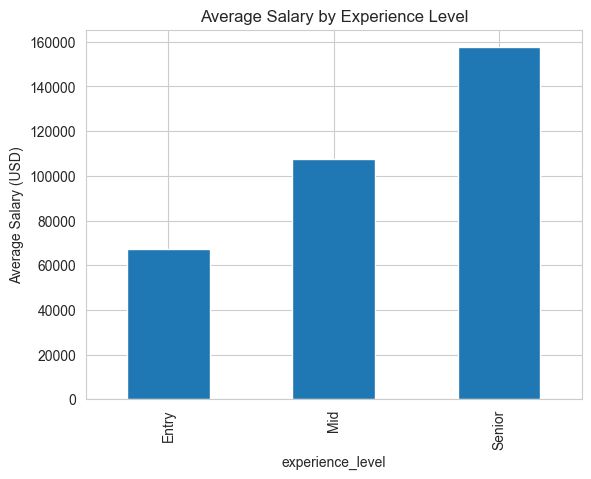

In [10]:
import matplotlib.pyplot as plt

df.groupby("experience_level")["avg_salary_usd"].mean().plot(kind="bar")
plt.title("Average Salary by Experience Level")
plt.ylabel("Average Salary (USD)")
plt.show()

# Does Company Size Affect Salary?

In [11]:
df.groupby("company_size")["avg_salary_usd"].mean().sort_values()

company_size
Medium    110765.317795
Small     110903.200876
Large     110926.278492
Name: avg_salary_usd, dtype: float64

# Test Country's Impact

In [12]:
df.groupby("country")["avg_salary_usd"].mean().sort_values(ascending=False)

country
Australia    111485.412337
USA          111057.537165
UK           111039.290582
Germany      110897.890294
India        110396.954910
Canada       110314.312839
Name: avg_salary_usd, dtype: float64

# If experience overrides country

In [13]:
pd.pivot_table(
    df,
    values="avg_salary_usd",
    index="country",
    columns="experience_level",
    aggfunc="mean"
)

experience_level,Entry,Mid,Senior
country,,,
Australia,67601.891409,107513.104384,157511.703638
Canada,67446.498749,107631.027471,157488.773501
Germany,67430.324154,107465.930586,157397.604427
India,67614.812697,107445.562408,157507.087821
UK,67345.685796,107455.224876,157532.010747
USA,67400.859536,107530.166488,157503.643038


# If work flexibility changes pay

In [14]:
df.groupby("remote_type")["avg_salary_usd"].mean().sort_values()

remote_type
Onsite    110506.855091
Remote    110910.661033
Hybrid    111169.122969
Name: avg_salary_usd, dtype: float64

# Let’s analyze market demand trends over time

In [15]:
df["posted_year"].value_counts().sort_index()

posted_year
2020    7205
2021    7128
2022    7135
2023    7035
2024    7312
2025    7043
2026    7142
Name: count, dtype: int64

In [16]:
pd.crosstab(df["posted_year"], df["experience_level"])

experience_level,Entry,Mid,Senior
posted_year,,,
2020,2416,2388,2401
2021,2364,2315,2449
2022,2345,2441,2349
2023,2310,2334,2391
2024,2467,2441,2404
2025,2337,2396,2310
2026,2389,2380,2373


# Experience affects salary

In [17]:
df.groupby("experience_level")["avg_salary_usd"].mean().diff()

experience_level
Entry              NaN
Mid       40033.616351
Senior    49983.054310
Name: avg_salary_usd, dtype: float64

# Let’s check distribution overlap

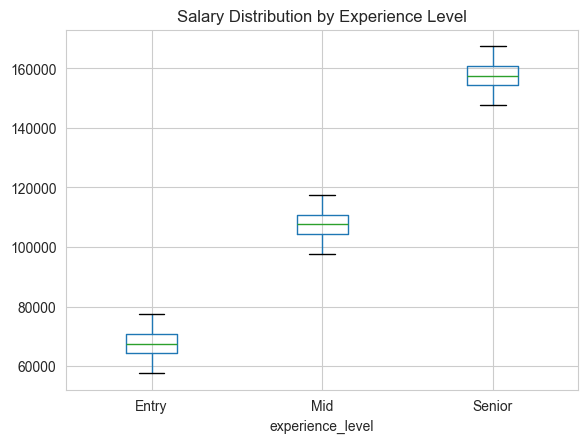

In [18]:
df.boxplot(column="avg_salary_usd", by="experience_level")
plt.title("Salary Distribution by Experience Level")
plt.suptitle("")
plt.show()

# Prepare Data for Modeling

In [19]:
# Copy dataset
model_df = df.copy()

# Convert experience_level to numeric
model_df["experience_level"] = model_df["experience_level"].map({
    "Entry": 0,
    "Mid": 1,
    "Senior": 2
})

model_df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size,avg_salary_usd
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,0,0,56873,72223,Full-time,2023,Large,64548.0
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,0,0,54803,85599,Full-time,2024,Medium,70201.0
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,2,5,149980,175806,Full-time,2021,Large,162893.0
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,0,0,53483,86477,Full-time,2023,Medium,69980.0
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,1,2,102977,127298,Full-time,2023,Large,115137.5


In [20]:
# Drop unnecessary columns
model_df = model_df.drop(columns=["job_id", "salary_min_usd", "salary_max_usd"])

# One-hot encoding categorical variables
model_df = pd.get_dummies(model_df, drop_first=True)

model_df.head()

,experience_level,min_experience_years,posted_year,avg_salary_usd,job_title_Applied Scientist,job_title_Data Analyst,job_title_Data Scientist,job_title_MLOps Engineer,job_title_Machine Learning Engineer,company_type_Research Lab,...,city_Remote,city_San Francisco,city_Seattle,city_Sydney,city_Toronto,city_Vancouver,remote_type_Onsite,remote_type_Remote,company_size_Medium,company_size_Small
0,0,0,2023,64548.0,False,False,False,True,False,True,...,True,False,False,False,False,False,False,True,False,False
1,0,0,2024,70201.0,False,True,False,False,False,False,...,True,False,False,False,False,False,False,True,True,False
2,2,5,2021,162893.0,False,False,False,True,False,True,...,True,False,False,False,False,False,False,True,False,False
3,0,0,2023,69980.0,True,False,False,False,False,True,...,True,False,False,False,False,False,False,True,True,False
4,1,2,2023,115137.5,False,False,False,False,True,True,...,False,False,False,True,False,False,False,False,False,False


# Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split

# Define X and y
X = model_df.drop("avg_salary_usd", axis=1)
y = model_df["avg_salary_usd"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((40000, 46), (10000, 46))

# Train Linear Regression Mode

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: 0.9869500556763308
Mean Absolute Error: 3521.3735339044474


In [23]:
import pandas as pd

# Create dataframe of feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Sort by absolute importance
feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(
    "Abs_Coefficient", ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
0,experience_level,20233.943904,20233.943904
1,min_experience_years,9903.667537,9903.667537
25,city_Delhi,717.303217,717.303217
28,city_Hyderabad,542.900094,542.900094
27,city_Hamburg,438.508993,438.508993
24,city_Chennai,416.428599,416.428599
19,city_Bangalore,414.011570,414.011570
21,city_Birmingham,385.794101,385.794101
35,city_Pune,365.689041,365.689041
20,city_Berlin,354.181313,354.181313


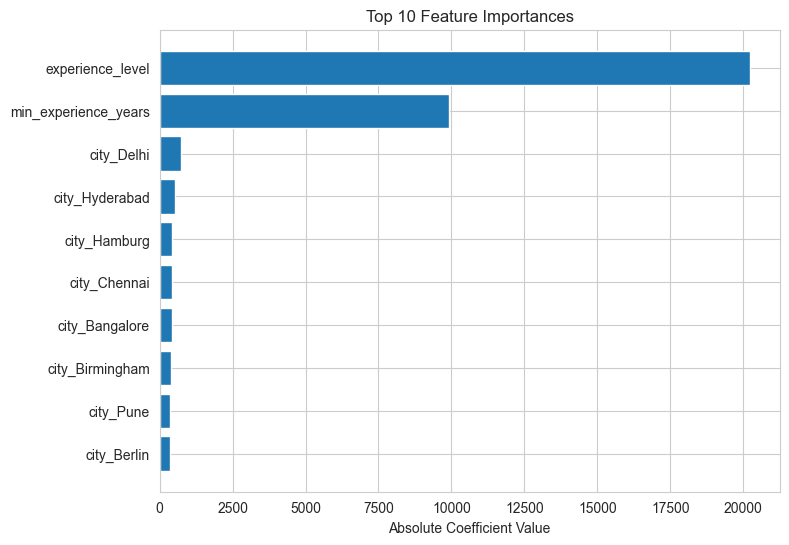

In [24]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Abs_Coefficient"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Absolute Coefficient Value")
plt.show()

# Train Random Forest Regressor

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest R2:", rf_r2)
print("Random Forest MAE:", rf_mae)

Random Forest R2: 0.9849989825929777
Random Forest MAE: 3734.9298870556922


In [26]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance", ascending=False
)

rf_importance.head(10)

,Feature,Importance
1,min_experience_years,0.505914
0,experience_level,0.481998
2,posted_year,0.001969
8,company_type_Research Lab,0.000580
44,company_size_Medium,0.000578
9,company_type_Startup,0.000566
45,company_size_Small,0.000546
42,remote_type_Onsite,0.000527
13,industry_Tech,0.000471
12,industry_Retail,0.000429
